# Monty Hall: Full Simulation Lab

This notebook turns the Monty Hall problem into a broader probability experiment.

It studies not only the classic 3-door game, but also:

- many different numbers of doors,
- different numbers of doors revealed by Monty,
- the value of information as Monty reveals more losing doors,
- repeated experiments and sampling variability,
- 95% confidence intervals,
- reproducible random seeds,
- informed vs. uninformed hosts,
- cases where an uninformed host accidentally reveals the prize,
- strategy variants,
- simulation error versus theoretical probability,
- and an optional interactive experiment panel.

The notebook performs its own simulations. A separate `simulator.py` is included for command-line CSV export.

## Two host models

### Informed host

Monty **knows** where the prize is and only reveals losing doors.

If more than one alternative remains closed, a switching player chooses uniformly at random from the remaining unopened alternatives.

### Uninformed host

Monty **does not know** where the prize is. He reveals random doors other than the player's current choice.

He may accidentally reveal the prize. Those rounds are tracked separately as `Host revealed prize`.

If he does not reveal the prize, a switching player chooses uniformly at random from the remaining unopened alternatives.

This distinction matters: an informed reveal contains information; an uninformed reveal does not provide the same advantage.

## 1. Imports and settings

The defaults are large enough to make the patterns visible while still running comfortably on a normal laptop.

Set `SAVE_PLOTS = True` if you want PNG copies of figures saved to `plots/`.

In [69]:
from pathlib import Path
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_SEED = 42
BASE_GAMES = 100_000

SAMPLE_SIZES = [10, 100, 1_000, 10_000, 100_000]
ERROR_REPEATS = 20

BATCH_COUNT = 100
BATCH_SIZE = 1_000

DOOR_COUNTS = [3, 4, 5, 10, 25, 100]
GAMES_PER_DOOR_COUNT = 50_000

HOST_COMPARE_GAMES = 20_000
STABILITY_BATCHES = 50
STABILITY_BATCH_SIZE = 1_000

SAVE_PLOTS = False
PLOTS_DIR = Path("plots")

if SAVE_PLOTS:
    PLOTS_DIR.mkdir(exist_ok=True)

def finish_plot(filename):
    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

## 2. Exact theoretical probabilities

For `N` doors and `R` revealed doors:

### Informed host

The host avoids the prize.

- Staying wins with probability `1 / N`.
- If the initial choice is wrong, the prize is among the remaining alternatives.
- After `R` losing doors are removed, there are `N - 1 - R` unopened alternatives to switch to.

Therefore:

`P(switch) = (N - 1) / [N × (N - 1 - R)]`

The classic generalized Monty Hall problem is the endpoint `R = N - 2`.

### Uninformed host

The host reveals random unchosen doors and can expose the prize.

- Probability the host reveals the prize: `R / N`.
- If aborted rounds count as no win, both staying and random switching win with probability `1 / N`.
- Conditional on the host **not** revealing the prize, both strategies win with probability `1 / (N - R)`.

That equality is the important result: once the host does not know where the prize is, seeing losing doors does not create the same switching advantage.

In [70]:
def validate_scenario(n_doors, reveals):
    if n_doors < 3:
        raise ValueError("There must be at least 3 doors.")
    if reveals < 0:
        raise ValueError("reveals cannot be negative.")
    if reveals > n_doors - 2:
        raise ValueError(
            f"With {n_doors} doors, reveals must be between 0 and {n_doors - 2} "
            "so at least one alternative remains available."
        )


def informed_theory(n_doors, reveals):
    validate_scenario(n_doors, reveals)

    stay = 1 / n_doors
    switch = (n_doors - 1) / (
        n_doors * (n_doors - 1 - reveals)
    )

    return {
        "Stay": stay,
        "Switch": switch,
        "Advantage": switch - stay,
        "Host Reveals Prize": 0.0,
    }


def uninformed_theory(n_doors, reveals):
    validate_scenario(n_doors, reveals)

    abort = reveals / n_doors
    unconditional = 1 / n_doors
    conditional = 1 / (n_doors - reveals)

    return {
        "Stay Unconditional": unconditional,
        "Switch Unconditional": unconditional,
        "Stay Conditional": conditional,
        "Switch Conditional": conditional,
        "Host Reveals Prize": abort,
    }

## 3. Fast simulation engine

This version is optimized for repeated statistical experiments. It simulates the relevant events without constructing a full door list on every trial.

For an uninformed host, a round can be aborted when the prize is revealed. The results report both:

- **unconditional** rates, where aborted rounds count as no win,
- **completed-round** rates, conditioned on the prize not being revealed.

In [71]:
def simulate_rates(
    n_games,
    n_doors=3,
    reveals=1,
    host_knows=True,
    seed=None,
):
    validate_scenario(n_doors, reveals)

    if n_games < 1:
        raise ValueError("n_games must be at least 1.")

    rng = random.Random(seed)

    stay_wins = 0
    switch_wins = 0
    host_revealed_prize = 0
    completed = 0

    remaining_switch_options = n_doors - 1 - reveals

    for _ in range(n_games):
        prize_index = rng.randrange(n_doors)
        choice_index = rng.randrange(n_doors)

        initial_correct = choice_index == prize_index

        if host_knows:
            completed += 1

            if initial_correct:
                stay_wins += 1
            else:
                if rng.randrange(remaining_switch_options) == 0:
                    switch_wins += 1

        else:
            if initial_correct:
                # The prize is the player's chosen door, so the host cannot
                # reveal it because the player's door is excluded.
                completed += 1
                stay_wins += 1
            else:
                # Among N-1 unchosen doors, R are revealed uniformly.
                # The prize is hit with probability R/(N-1).
                prize_revealed = rng.randrange(n_doors - 1) < reveals

                if prize_revealed:
                    host_revealed_prize += 1
                    continue

                completed += 1

                if rng.randrange(remaining_switch_options) == 0:
                    switch_wins += 1

    return {
        "Games": n_games,
        "Completed": completed,
        "Host Revealed Prize": host_revealed_prize,
        "Host Revealed Prize Rate": host_revealed_prize / n_games,
        "Stay Wins": stay_wins,
        "Switch Wins": switch_wins,
        "Stay Win Rate": stay_wins / n_games,
        "Switch Win Rate": switch_wins / n_games,
        "Stay Completed Win Rate": stay_wins / completed if completed else float("nan"),
        "Switch Completed Win Rate": switch_wins / completed if completed else float("nan"),
    }

## 4. Detailed trial simulation

For the baseline experiment, it is useful to retain every trial so we can plot cumulative wins and running win rates.

In [72]:
def simulate_trials(
    n_games,
    n_doors=3,
    reveals=1,
    host_knows=True,
    seed=None,
):
    validate_scenario(n_doors, reveals)

    rng = random.Random(seed)
    rows = []

    for iteration in range(1, n_games + 1):
        prize = rng.randrange(n_doors)
        choice = rng.randrange(n_doors)

        available_to_host = [door for door in range(n_doors) if door != choice]

        if host_knows:
            host_candidates = [
                door
                for door in available_to_host
                if door != prize
            ]
            revealed = rng.sample(host_candidates, reveals)
            prize_revealed = False
        else:
            revealed = rng.sample(available_to_host, reveals)
            prize_revealed = prize in revealed

        switch_options = [
            door
            for door in range(n_doors)
            if door != choice and door not in revealed
        ]

        if prize_revealed:
            switch_door = None
            switch_win = False
            completed = False
        else:
            switch_door = rng.choice(switch_options)
            switch_win = switch_door == prize
            completed = True

        stay_win = choice == prize

        rows.append(
            {
                "Iteration": iteration,
                "Doors": n_doors,
                "Revealed": reveals,
                "Host Knows": host_knows,
                "Prize Door": prize + 1,
                "Initial Choice": choice + 1,
                "Host Revealed Prize": prize_revealed,
                "Completed": completed,
                "Stay Win": stay_win,
                "Switch Win": switch_win,
            }
        )

    return pd.DataFrame(rows)

## 5. Reproducibility with a random seed

The same seed and the same settings should generate the same pseudo-random experiment.

In [39]:
a = simulate_rates(
    10_000,
    n_doors=3,
    reveals=1,
    host_knows=True,
    seed=BASE_SEED,
)

b = simulate_rates(
    10_000,
    n_doors=3,
    reveals=1,
    host_knows=True,
    seed=BASE_SEED,
)

assert a == b

print("Same seed produced identical results:", a == b)
a

Same seed produced identical results: True


{'Games': 10000,
 'Completed': 10000,
 'Host Revealed Prize': 0,
 'Host Revealed Prize Rate': 0.0,
 'Stay Wins': 3400,
 'Switch Wins': 6600,
 'Stay Win Rate': 0.34,
 'Switch Win Rate': 0.66,
 'Stay Completed Win Rate': 0.34,
 'Switch Completed Win Rate': 0.66}

# Part I — Classic 3-door Monty Hall

## 6. Baseline simulation

In [40]:
baseline = simulate_trials(
    BASE_GAMES,
    n_doors=3,
    reveals=1,
    host_knows=True,
    seed=BASE_SEED,
)

baseline.head(10)

,Iteration,Doors,Revealed,Host Knows,Prize Door,Initial Choice,Host Revealed Prize,Completed,Stay Win,Switch Win
0,1,3,1,True,3,1,False,True,False,True
1,2,3,1,True,1,1,False,True,True,False
2,3,3,1,True,3,3,False,True,True,False
3,4,3,1,True,1,1,False,True,True,False
4,5,3,1,True,1,3,False,True,False,True
5,6,3,1,True,3,3,False,True,True,False
6,7,3,1,True,2,3,False,True,False,True
7,8,3,1,True,1,3,False,True,False,True
8,9,3,1,True,2,1,False,True,False,True
9,10,3,1,True,1,1,False,True,True,False


## 7. Summary table

In [41]:
baseline_summary = pd.DataFrame(
    {
        "Strategy": ["Keep original choice", "Switch"],
        "Games": [len(baseline), len(baseline)],
        "Wins": [
            baseline["Stay Win"].sum(),
            baseline["Switch Win"].sum(),
        ],
    }
)

baseline_summary["Losses"] = (
    baseline_summary["Games"] - baseline_summary["Wins"]
)

baseline_summary["Win Rate (%)"] = (
    baseline_summary["Wins"] / baseline_summary["Games"] * 100
).round(3)

baseline_summary

,Strategy,Games,Wins,Losses,Win Rate (%)
0,Keep original choice,100000,33506,66494,33.506
1,Switch,100000,66494,33506,66.494


## 8. 95% Wilson confidence intervals

In [42]:
def wilson_interval(wins, n, z=1.96):
    if n <= 0:
        raise ValueError("n must be positive.")

    p_hat = wins / n
    z2 = z ** 2

    denominator = 1 + z2 / n
    center = (p_hat + z2 / (2 * n)) / denominator

    margin = (
        z
        * math.sqrt(
            (p_hat * (1 - p_hat) / n)
            + (z2 / (4 * n ** 2))
        )
        / denominator
    )

    return center - margin, center + margin


ci_rows = []

for _, row in baseline_summary.iterrows():
    low, high = wilson_interval(
        int(row["Wins"]),
        int(row["Games"]),
    )

    ci_rows.append(
        {
            "Strategy": row["Strategy"],
            "Games": int(row["Games"]),
            "Wins": int(row["Wins"]),
            "Win Rate (%)": row["Win Rate (%)"],
            "95% CI Low (%)": low * 100,
            "95% CI High (%)": high * 100,
        }
    )

ci_table = pd.DataFrame(ci_rows)
ci_table.round(3)

,Strategy,Games,Wins,Win Rate (%),95% CI Low (%),95% CI High (%)
0,Keep original choice,100000,33506,33.506,33.214,33.799
1,Switch,100000,66494,66.494,66.201,66.786


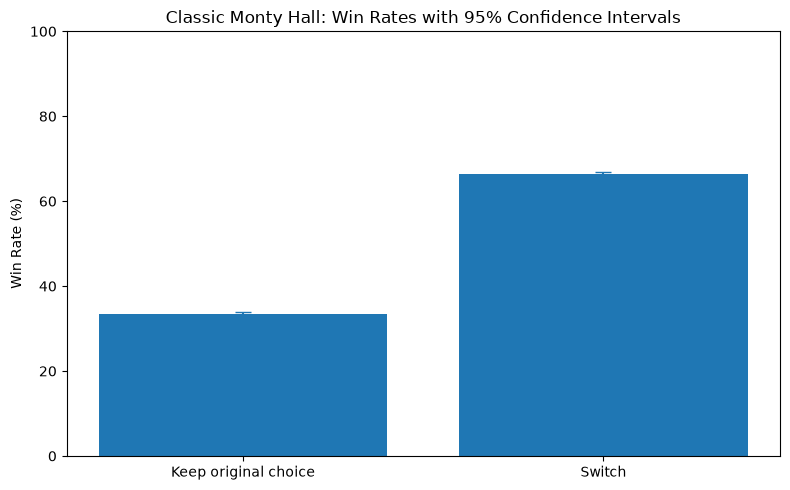

In [43]:
rates = ci_table["Win Rate (%)"]
lower_errors = rates - ci_table["95% CI Low (%)"]
upper_errors = ci_table["95% CI High (%)"] - rates

plt.figure(figsize=(8, 5))
plt.bar(ci_table["Strategy"], rates)

plt.errorbar(
    ci_table["Strategy"],
    rates,
    yerr=[lower_errors, upper_errors],
    fmt="none",
    capsize=6,
)

plt.ylabel("Win Rate (%)")
plt.title("Classic Monty Hall: Win Rates with 95% Confidence Intervals")
plt.ylim(0, 100)

finish_plot("classic_confidence_intervals.png")

## 9. Cumulative wins

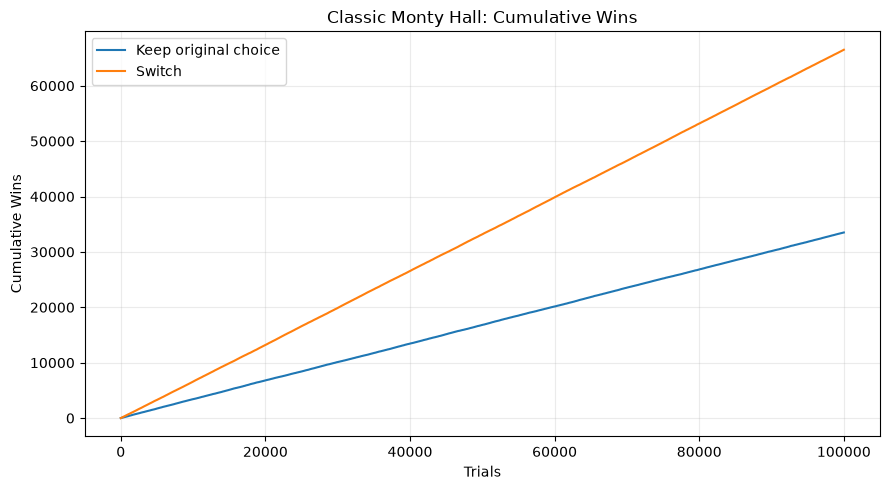

In [44]:
baseline["Stay Cumulative Wins"] = baseline["Stay Win"].cumsum()
baseline["Switch Cumulative Wins"] = baseline["Switch Win"].cumsum()

plt.figure(figsize=(9, 5))

plt.plot(
    baseline["Iteration"],
    baseline["Stay Cumulative Wins"],
    label="Keep original choice",
)

plt.plot(
    baseline["Iteration"],
    baseline["Switch Cumulative Wins"],
    label="Switch",
)

plt.xlabel("Trials")
plt.ylabel("Cumulative Wins")
plt.title("Classic Monty Hall: Cumulative Wins")
plt.legend()
plt.grid(alpha=0.25)

finish_plot("classic_cumulative_wins.png")

## 10. Running win rate and theoretical reference lines

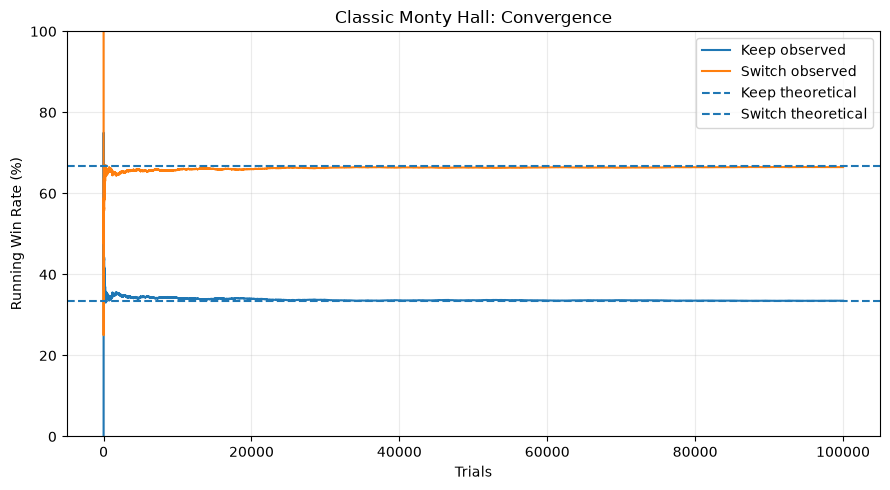

In [45]:
baseline["Stay Running Win Rate (%)"] = (
    baseline["Stay Win"].expanding().mean() * 100
)

baseline["Switch Running Win Rate (%)"] = (
    baseline["Switch Win"].expanding().mean() * 100
)

plt.figure(figsize=(9, 5))

plt.plot(
    baseline["Iteration"],
    baseline["Stay Running Win Rate (%)"],
    label="Keep observed",
)

plt.plot(
    baseline["Iteration"],
    baseline["Switch Running Win Rate (%)"],
    label="Switch observed",
)

plt.axhline(
    100 / 3,
    linestyle="--",
    label="Keep theoretical",
)

plt.axhline(
    200 / 3,
    linestyle="--",
    label="Switch theoretical",
)

plt.xlabel("Trials")
plt.ylabel("Running Win Rate (%)")
plt.title("Classic Monty Hall: Convergence")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.25)

finish_plot("classic_running_win_rate.png")

## 11. Convergence snapshots

Instead of an animation, this table and plot take snapshots of the same experiment after increasingly large numbers of trials.

In [46]:
snapshot_rows = []

for size in SAMPLE_SIZES:
    subset = baseline.iloc[:min(size, len(baseline))]

    snapshot_rows.append(
        {
            "Trials": len(subset),
            "Keep (%)": subset["Stay Win"].mean() * 100,
            "Switch (%)": subset["Switch Win"].mean() * 100,
        }
    )

snapshot_df = pd.DataFrame(snapshot_rows).drop_duplicates("Trials")
snapshot_df.round(3)

,Trials,Keep (%),Switch (%)
0,10,50.000,50.000
1,100,40.000,60.000
2,1000,34.100,65.900
3,10000,34.180,65.820
4,100000,33.506,66.494


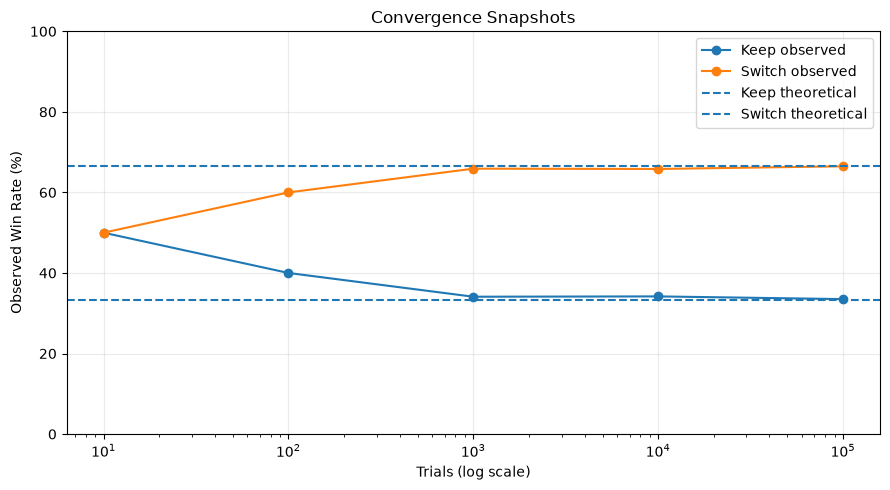

In [47]:
plt.figure(figsize=(9, 5))

plt.plot(
    snapshot_df["Trials"],
    snapshot_df["Keep (%)"],
    marker="o",
    label="Keep observed",
)

plt.plot(
    snapshot_df["Trials"],
    snapshot_df["Switch (%)"],
    marker="o",
    label="Switch observed",
)

plt.axhline(100 / 3, linestyle="--", label="Keep theoretical")
plt.axhline(200 / 3, linestyle="--", label="Switch theoretical")

plt.xscale("log")
plt.xlabel("Trials (log scale)")
plt.ylabel("Observed Win Rate (%)")
plt.title("Convergence Snapshots")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.25)

finish_plot("convergence_snapshots.png")

# Part II — Sample size, repeated batches, and uncertainty

## 12. Error versus sample size

For each sample size, several independent experiments are run. The graph shows the average absolute error from the exact theoretical probability.

In [48]:
error_records = []

for size_index, sample_size in enumerate(SAMPLE_SIZES):
    for repeat in range(ERROR_REPEATS):
        result = simulate_rates(
            sample_size,
            n_doors=3,
            reveals=1,
            host_knows=True,
            seed=BASE_SEED + 10_000 * (size_index + 1) + repeat,
        )

        stay_error = abs(result["Stay Win Rate"] - (1 / 3))
        switch_error = abs(result["Switch Win Rate"] - (2 / 3))

        error_records.append(
            {
                "Sample Size": sample_size,
                "Repeat": repeat + 1,
                "Stay Error (%)": stay_error * 100,
                "Switch Error (%)": switch_error * 100,
                "Mean Absolute Error (%)": (
                    (stay_error + switch_error) / 2 * 100
                ),
            }
        )

error_df = pd.DataFrame(error_records)

error_summary = (
    error_df.groupby("Sample Size")["Mean Absolute Error (%)"]
    .agg(["mean", "median", "max"])
    .reset_index()
    .rename(
        columns={
            "mean": "Mean Error (%)",
            "median": "Median Error (%)",
            "max": "Maximum Error (%)",
        }
    )
)

error_summary.round(4)

,Sample Size,Mean Error (%),Median Error (%),Maximum Error (%)
0,10,10.6667,6.6667,23.3333
1,100,3.4333,3.0000,8.3333
2,1000,1.7533,1.5500,3.7333
3,10000,0.3660,0.3450,1.3067
4,100000,0.1096,0.0743,0.3443


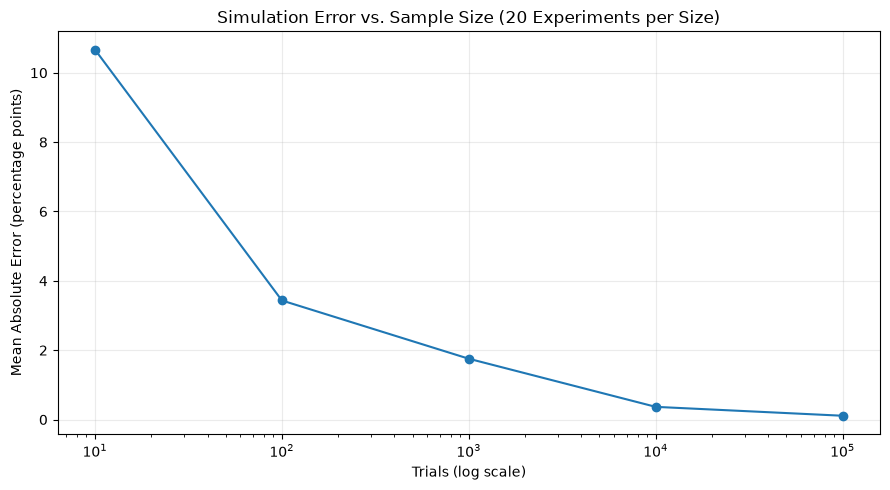

In [49]:
plt.figure(figsize=(9, 5))

plt.plot(
    error_summary["Sample Size"],
    error_summary["Mean Error (%)"],
    marker="o",
)

plt.xscale("log")
plt.xlabel("Trials (log scale)")
plt.ylabel("Mean Absolute Error (percentage points)")
plt.title(
    f"Simulation Error vs. Sample Size "
    f"({ERROR_REPEATS} Experiments per Size)"
)
plt.grid(alpha=0.25)

finish_plot("sample_size_error.png")

## 13. Repeated batches

A single simulation can land above or below the true probability. Repeated batches show the distribution of those observed rates.

In [50]:
batch_records = []

for batch in range(BATCH_COUNT):
    result = simulate_rates(
        BATCH_SIZE,
        n_doors=3,
        reveals=1,
        host_knows=True,
        seed=BASE_SEED + 500_000 + batch,
    )

    batch_records.append(
        {
            "Batch": batch + 1,
            "Keep Win Rate (%)": result["Stay Win Rate"] * 100,
            "Switch Win Rate (%)": result["Switch Win Rate"] * 100,
        }
    )

batch_df = pd.DataFrame(batch_records)
batch_df.describe().round(3)

,Batch,Keep Win Rate (%),Switch Win Rate (%)
count,100.000,100.000,100.000
mean,50.500,33.246,66.754
std,29.011,1.373,1.373
min,1.000,29.400,63.000
25%,25.750,32.300,66.100
50%,50.500,33.100,66.900
75%,75.250,33.900,67.700
max,100.000,37.000,70.600


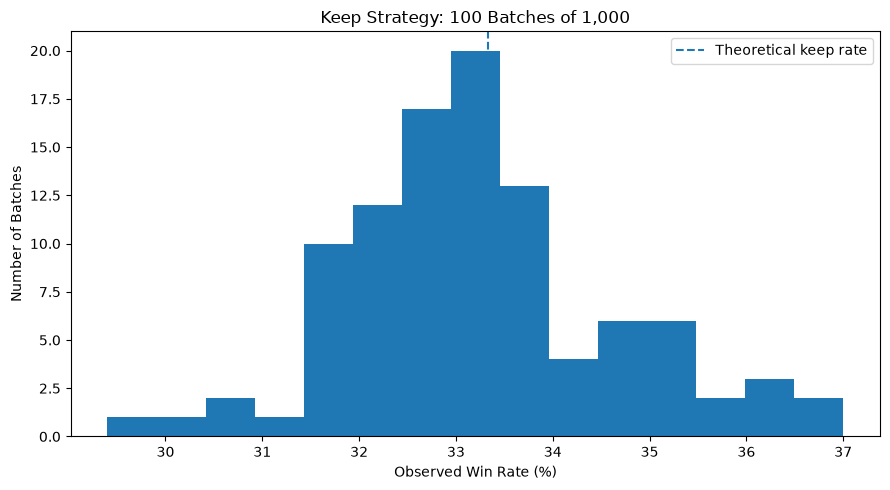

In [51]:
plt.figure(figsize=(9, 5))
plt.hist(batch_df["Keep Win Rate (%)"], bins=15)
plt.axvline(100 / 3, linestyle="--", label="Theoretical keep rate")
plt.xlabel("Observed Win Rate (%)")
plt.ylabel("Number of Batches")
plt.title(f"Keep Strategy: {BATCH_COUNT} Batches of {BATCH_SIZE:,}")
plt.legend()

finish_plot("keep_batches.png")

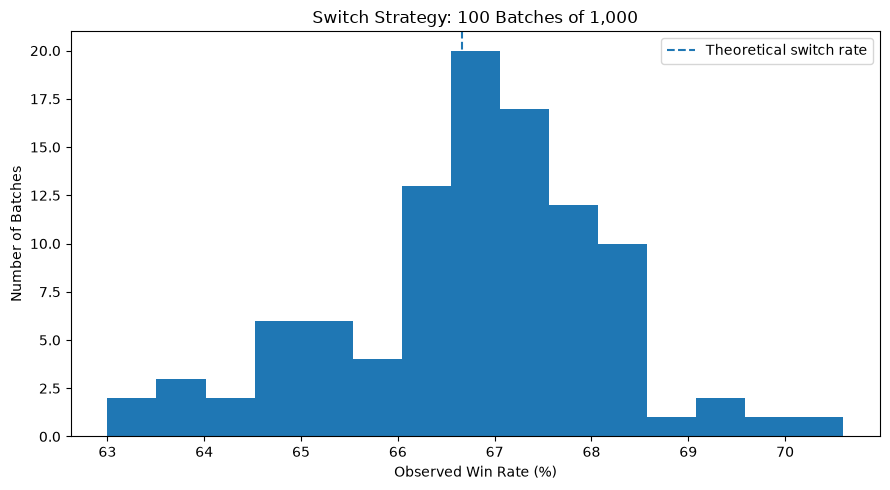

In [52]:
plt.figure(figsize=(9, 5))
plt.hist(batch_df["Switch Win Rate (%)"], bins=15)
plt.axvline(200 / 3, linestyle="--", label="Theoretical switch rate")
plt.xlabel("Observed Win Rate (%)")
plt.ylabel("Number of Batches")
plt.title(f"Switch Strategy: {BATCH_COUNT} Batches of {BATCH_SIZE:,}")
plt.legend()

finish_plot("switch_batches.png")

# Part III — More doors

## 14. Classic generalized Monty: reveal all possible losing doors

This is the version where Monty leaves only the player's original choice and one alternative closed.

With 100 doors, Monty reveals 98 losing doors.

In [53]:
generalized_rows = []

for n_doors in DOOR_COUNTS:
    reveals = n_doors - 2

    result = simulate_rates(
        GAMES_PER_DOOR_COUNT,
        n_doors=n_doors,
        reveals=reveals,
        host_knows=True,
        seed=BASE_SEED + 1_000_000 + n_doors,
    )

    theory = informed_theory(n_doors, reveals)

    generalized_rows.append(
        {
            "Doors": n_doors,
            "Revealed": reveals,
            "Observed Keep (%)": result["Stay Win Rate"] * 100,
            "Theoretical Keep (%)": theory["Stay"] * 100,
            "Observed Switch (%)": result["Switch Win Rate"] * 100,
            "Theoretical Switch (%)": theory["Switch"] * 100,
        }
    )

generalized_df = pd.DataFrame(generalized_rows)
generalized_df.round(3)

,Doors,Revealed,Observed Keep (%),Theoretical Keep (%),Observed Switch (%),Theoretical Switch (%)
0,3,1,33.134,33.333,66.866,66.667
1,4,2,25.086,25.000,74.914,75.000
2,5,3,19.934,20.000,80.066,80.000
3,10,8,9.838,10.000,90.162,90.000
4,25,23,4.146,4.000,95.854,96.000
5,100,98,0.972,1.000,99.028,99.000


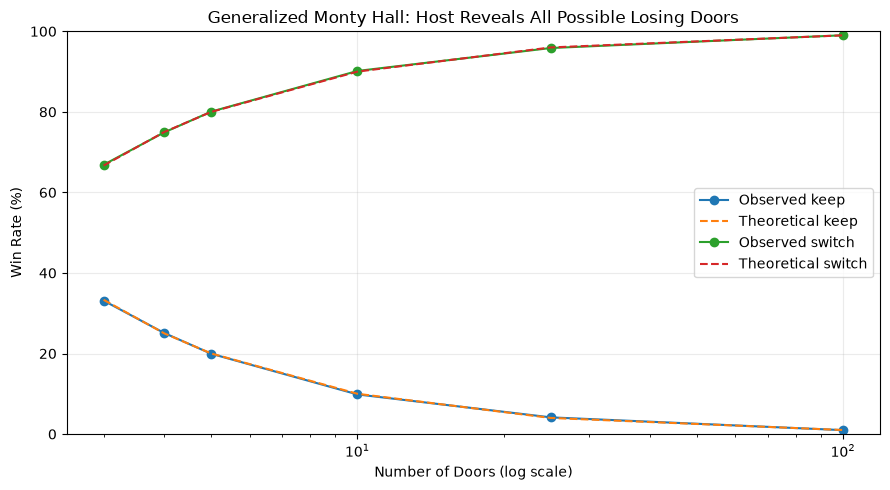

In [54]:
plt.figure(figsize=(9, 5))

plt.plot(
    generalized_df["Doors"],
    generalized_df["Observed Keep (%)"],
    marker="o",
    label="Observed keep",
)

plt.plot(
    generalized_df["Doors"],
    generalized_df["Theoretical Keep (%)"],
    linestyle="--",
    label="Theoretical keep",
)

plt.plot(
    generalized_df["Doors"],
    generalized_df["Observed Switch (%)"],
    marker="o",
    label="Observed switch",
)

plt.plot(
    generalized_df["Doors"],
    generalized_df["Theoretical Switch (%)"],
    linestyle="--",
    label="Theoretical switch",
)

plt.xscale("log")
plt.xlabel("Number of Doors (log scale)")
plt.ylabel("Win Rate (%)")
plt.title("Generalized Monty Hall: Host Reveals All Possible Losing Doors")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.25)

finish_plot("generalized_max_reveal.png")

# Part IV — How many doors Monty reveals

## 15. Exact reveal-count sweep

This section asks a more general question:

> How much does switching help as Monty reveals more losing doors?

The player switches uniformly at random among the remaining unopened alternatives.

In [55]:
reveal_sweep_rows = []

for n_doors in DOOR_COUNTS:
    for reveals in range(0, n_doors - 1):
        theory = informed_theory(n_doors, reveals)

        reveal_sweep_rows.append(
            {
                "Doors": n_doors,
                "Revealed": reveals,
                "Reveal Fraction": (
                    reveals / (n_doors - 2)
                    if n_doors > 2
                    else 0
                ),
                "Keep (%)": theory["Stay"] * 100,
                "Switch (%)": theory["Switch"] * 100,
                "Switch Advantage (pp)": theory["Advantage"] * 100,
            }
        )

reveal_sweep_df = pd.DataFrame(reveal_sweep_rows)
reveal_sweep_df.head(10)

,Doors,Revealed,Reveal Fraction,Keep (%),Switch (%),Switch Advantage (pp)
0,3,0,0.000000,33.333333,33.333333,0.000000
1,3,1,1.000000,33.333333,66.666667,33.333333
2,4,0,0.000000,25.000000,25.000000,0.000000
3,4,1,0.500000,25.000000,37.500000,12.500000
4,4,2,1.000000,25.000000,75.000000,50.000000
5,5,0,0.000000,20.000000,20.000000,0.000000
6,5,1,0.333333,20.000000,26.666667,6.666667
7,5,2,0.666667,20.000000,40.000000,20.000000
8,5,3,1.000000,20.000000,80.000000,60.000000
9,10,0,0.000000,10.000000,10.000000,0.000000


## 16. Switch advantage versus fraction of available losing doors revealed

Using the reveal **fraction** makes games with different numbers of doors easier to compare on the same axis.

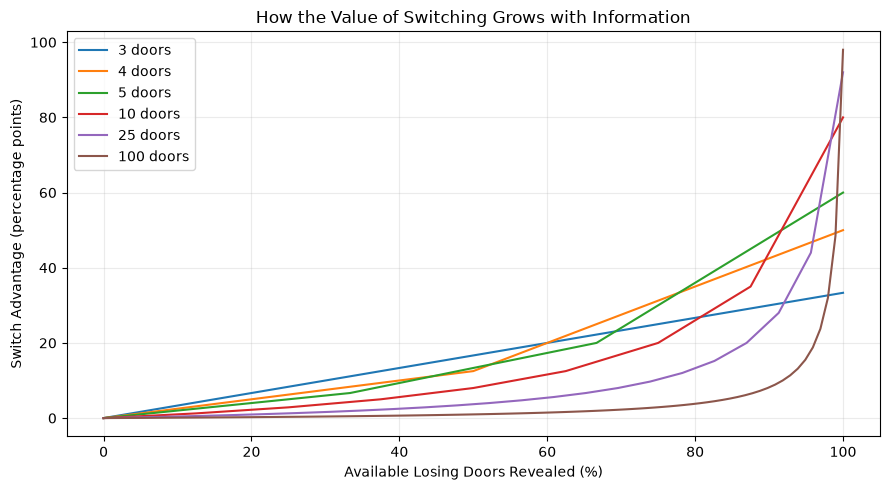

In [56]:
plt.figure(figsize=(9, 5))

for n_doors in DOOR_COUNTS:
    subset = reveal_sweep_df[reveal_sweep_df["Doors"] == n_doors]

    plt.plot(
        subset["Reveal Fraction"] * 100,
        subset["Switch Advantage (pp)"],
        label=f"{n_doors} doors",
    )

plt.xlabel("Available Losing Doors Revealed (%)")
plt.ylabel("Switch Advantage (percentage points)")
plt.title("How the Value of Switching Grows with Information")
plt.legend()
plt.grid(alpha=0.25)

finish_plot("reveal_fraction_advantage.png")

## 17. Heatmap: total doors × doors revealed

Each cell is the theoretical switching advantage in percentage points.

Blank cells are combinations that are impossible because too many doors would be revealed.

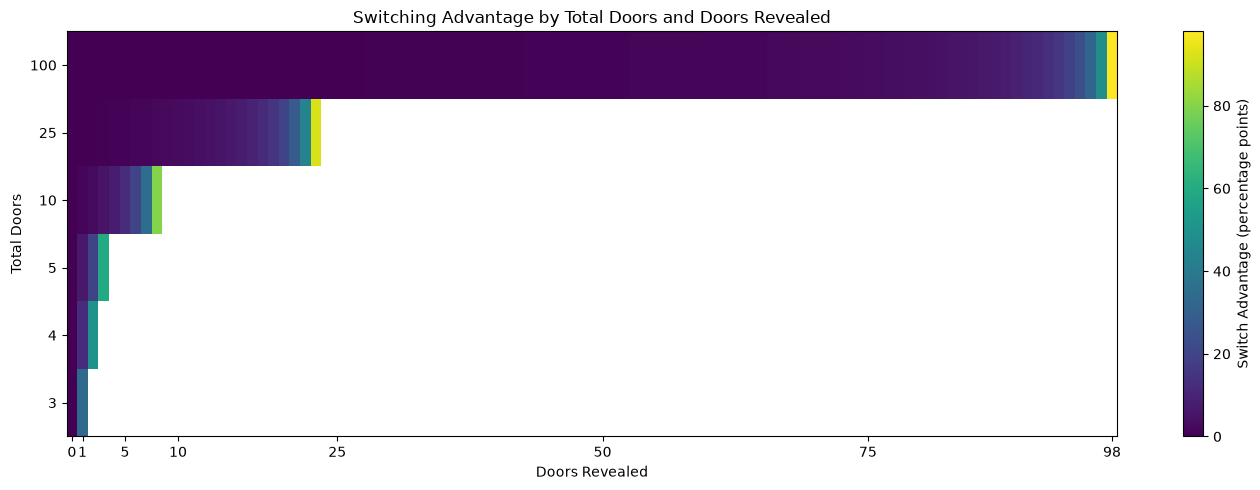

In [57]:
max_doors = max(DOOR_COUNTS)
max_reveals = max_doors - 2

heat = np.full(
    (len(DOOR_COUNTS), max_reveals + 1),
    np.nan,
)

for row_index, n_doors in enumerate(DOOR_COUNTS):
    for reveals in range(0, n_doors - 1):
        heat[row_index, reveals] = (
            informed_theory(n_doors, reveals)["Advantage"] * 100
        )

masked_heat = np.ma.masked_invalid(heat)

plt.figure(figsize=(14, 5))
image = plt.imshow(
    masked_heat,
    aspect="auto",
    origin="lower",
)

plt.colorbar(
    image,
    label="Switch Advantage (percentage points)",
)

plt.yticks(
    range(len(DOOR_COUNTS)),
    DOOR_COUNTS,
)

plt.xticks(
    [0, 1, 5, 10, 25, 50, 75, 98],
    [0, 1, 5, 10, 25, 50, 75, 98],
)

plt.xlabel("Doors Revealed")
plt.ylabel("Total Doors")
plt.title("Switching Advantage by Total Doors and Doors Revealed")

finish_plot("door_reveal_heatmap.png")

## 18. Minimum reveals needed for a meaningful advantage

This table finds the smallest number of losing doors Monty must reveal before switching improves the win rate by at least:

- 5 percentage points,
- 10 percentage points,
- 25 percentage points.

In [58]:
thresholds = [5, 10, 25]
minimum_rows = []

for n_doors in DOOR_COUNTS:
    row = {"Doors": n_doors}

    for threshold in thresholds:
        qualifying = reveal_sweep_df[
            (reveal_sweep_df["Doors"] == n_doors)
            & (
                reveal_sweep_df["Switch Advantage (pp)"]
                >= threshold
            )
        ]

        row[f"Reveals for ≥{threshold}pp"] = (
            int(qualifying["Revealed"].min())
            if not qualifying.empty
            else "Not achievable"
        )

    minimum_rows.append(row)

minimum_reveals_df = pd.DataFrame(minimum_rows)
minimum_reveals_df

,Doors,Reveals for ≥5pp,Reveals for ≥10pp,Reveals for ≥25pp
0,3,1,1,1
1,4,1,1,2
2,5,1,2,3
3,10,4,5,7
4,25,14,18,21
5,100,83,90,96


## 19. Strategy variants

For this example we use 25 doors and vary the number of doors Monty reveals.

Strategies:

- **Always stay**
- **Always switch**
- **Random 50/50** between stay and switch
- **Threshold strategy**: stay until at least half of all possible losing doors have been revealed, then switch

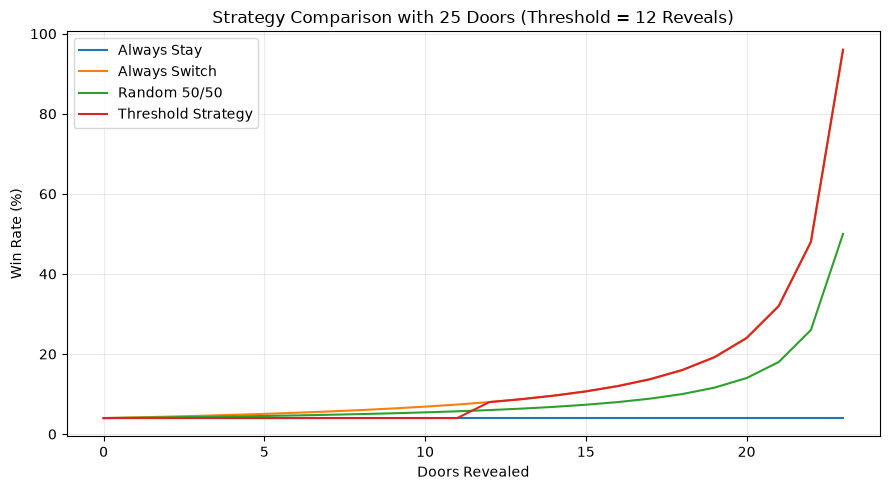

In [59]:
strategy_doors = 25
max_strategy_reveals = strategy_doors - 2
threshold_reveal = math.ceil(max_strategy_reveals / 2)

strategy_rows = []

for reveals in range(0, strategy_doors - 1):
    theory = informed_theory(strategy_doors, reveals)

    stay = theory["Stay"]
    switch = theory["Switch"]
    random_strategy = 0.5 * stay + 0.5 * switch
    threshold_strategy = (
        switch
        if reveals >= threshold_reveal
        else stay
    )

    strategy_rows.append(
        {
            "Revealed": reveals,
            "Always Stay (%)": stay * 100,
            "Always Switch (%)": switch * 100,
            "Random 50/50 (%)": random_strategy * 100,
            "Threshold Strategy (%)": threshold_strategy * 100,
        }
    )

strategy_df = pd.DataFrame(strategy_rows)

plt.figure(figsize=(9, 5))

for column in [
    "Always Stay (%)",
    "Always Switch (%)",
    "Random 50/50 (%)",
    "Threshold Strategy (%)",
]:
    plt.plot(
        strategy_df["Revealed"],
        strategy_df[column],
        label=column.replace(" (%)", ""),
    )

plt.xlabel("Doors Revealed")
plt.ylabel("Win Rate (%)")
plt.title(
    f"Strategy Comparison with {strategy_doors} Doors "
    f"(Threshold = {threshold_reveal} Reveals)"
)
plt.legend()
plt.grid(alpha=0.25)

finish_plot("strategy_variants.png")

# Part V — What if Monty does not know where the prize is?

## 20. Informed vs. uninformed host

This is a fundamentally different probability model.

An uninformed host can accidentally reveal the prize. The table below compares several scenarios using both exact probability and simulation.

In [60]:
comparison_scenarios = [
    (3, 1),
    (4, 1),
    (5, 1),
    (10, 1),
    (10, 4),
    (10, 8),
    (25, 1),
    (25, 12),
    (25, 23),
    (100, 1),
    (100, 50),
    (100, 98),
]

comparison_rows = []

for scenario_index, (n_doors, reveals) in enumerate(comparison_scenarios):
    for host_knows in [True, False]:
        simulation = simulate_rates(
            HOST_COMPARE_GAMES,
            n_doors=n_doors,
            reveals=reveals,
            host_knows=host_knows,
            seed=BASE_SEED + 2_000_000 + scenario_index * 10 + int(host_knows),
        )

        if host_knows:
            theory = informed_theory(n_doors, reveals)
            theoretical_switch = theory["Switch"]
            theoretical_abort = 0.0
        else:
            theory = uninformed_theory(n_doors, reveals)
            theoretical_switch = theory["Switch Unconditional"]
            theoretical_abort = theory["Host Reveals Prize"]

        comparison_rows.append(
            {
                "Doors": n_doors,
                "Revealed": reveals,
                "Host": "Informed" if host_knows else "Uninformed",
                "Observed Switch (%)": simulation["Switch Win Rate"] * 100,
                "Theoretical Switch (%)": theoretical_switch * 100,
                "Observed Prize Reveal (%)": (
                    simulation["Host Revealed Prize Rate"] * 100
                ),
                "Theoretical Prize Reveal (%)": theoretical_abort * 100,
            }
        )

host_comparison_df = pd.DataFrame(comparison_rows)
host_comparison_df.round(3)

,Doors,Revealed,Host,Observed Switch (%),Theoretical Switch (%),Observed Prize Reveal (%),Theoretical Prize Reveal (%)
0,3,1,Informed,66.525,66.667,0.000,0.000
1,3,1,Uninformed,33.290,33.333,33.405,33.333
2,4,1,Informed,37.455,37.500,0.000,0.000
3,4,1,Uninformed,24.755,25.000,25.360,25.000
4,5,1,Informed,26.490,26.667,0.000,0.000
5,5,1,Uninformed,20.100,20.000,19.715,20.000
6,10,1,Informed,11.520,11.250,0.000,0.000
7,10,1,Uninformed,9.790,10.000,10.030,10.000
8,10,4,Informed,18.200,18.000,0.000,0.000
9,10,4,Uninformed,9.845,10.000,40.510,40.000


## 21. Prize-reveal risk for an uninformed host

The exact probability that an uninformed host exposes the prize is:

`doors revealed / total doors`

So with 100 doors and 98 random reveals, the host reveals the prize 98% of the time.

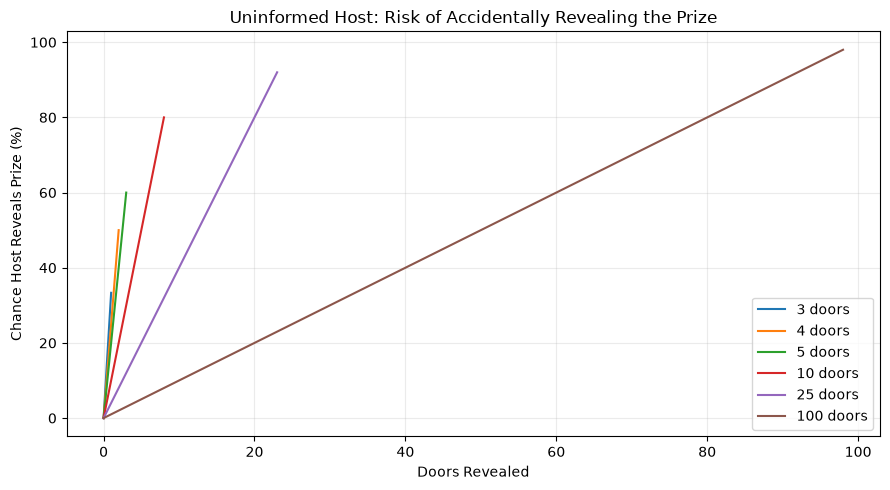

In [61]:
plt.figure(figsize=(9, 5))

for n_doors in DOOR_COUNTS:
    reveals = np.arange(0, n_doors - 1)
    prize_reveal_rate = reveals / n_doors * 100

    plt.plot(
        reveals,
        prize_reveal_rate,
        label=f"{n_doors} doors",
    )

plt.xlabel("Doors Revealed")
plt.ylabel("Chance Host Reveals Prize (%)")
plt.title("Uninformed Host: Risk of Accidentally Revealing the Prize")
plt.legend()
plt.grid(alpha=0.25)

finish_plot("uninformed_prize_reveal_risk.png")

## 22. Informed vs. uninformed switching with 100 doors

This plot makes the difference especially clear.

- An informed host increasingly concentrates probability into the remaining switch options.
- An uninformed host does not create the same unconditional switching advantage.

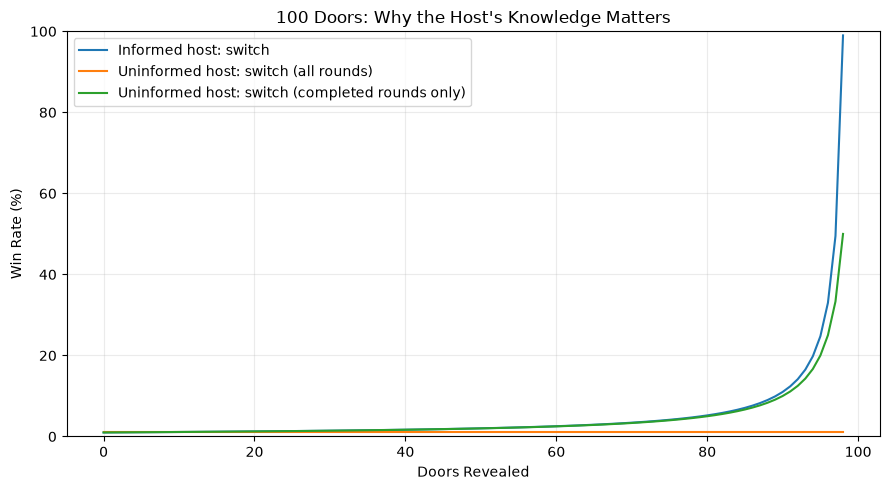

In [62]:
comparison_doors = 100
reveals = np.arange(0, comparison_doors - 1)

informed_switch = np.array(
    [
        informed_theory(comparison_doors, int(r))["Switch"]
        for r in reveals
    ]
) * 100

uninformed_switch = np.array(
    [
        uninformed_theory(comparison_doors, int(r))["Switch Unconditional"]
        for r in reveals
    ]
) * 100

uninformed_conditional = np.array(
    [
        uninformed_theory(comparison_doors, int(r))["Switch Conditional"]
        for r in reveals
    ]
) * 100

plt.figure(figsize=(9, 5))

plt.plot(
    reveals,
    informed_switch,
    label="Informed host: switch",
)

plt.plot(
    reveals,
    uninformed_switch,
    label="Uninformed host: switch (all rounds)",
)

plt.plot(
    reveals,
    uninformed_conditional,
    label="Uninformed host: switch (completed rounds only)",
)

plt.xlabel("Doors Revealed")
plt.ylabel("Win Rate (%)")
plt.title("100 Doors: Why the Host's Knowledge Matters")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.25)

finish_plot("informed_vs_uninformed_100_doors.png")

## 23. Classic 3-door case with an uninformed host

With three doors, if the host randomly opens one unchosen door:

- the host exposes the prize in some rounds,
- conditional on seeing a losing door, staying and switching are equally likely to win.

That is very different from classic Monty Hall, where the host deliberately avoids the prize.

In [63]:
classic_informed = informed_theory(3, 1)
classic_uninformed = uninformed_theory(3, 1)

pd.DataFrame(
    [
        {
            "Host": "Informed",
            "Prize Reveal Risk (%)": 0,
            "Stay (%)": classic_informed["Stay"] * 100,
            "Switch (%)": classic_informed["Switch"] * 100,
        },
        {
            "Host": "Uninformed — all rounds",
            "Prize Reveal Risk (%)": classic_uninformed["Host Reveals Prize"] * 100,
            "Stay (%)": classic_uninformed["Stay Unconditional"] * 100,
            "Switch (%)": classic_uninformed["Switch Unconditional"] * 100,
        },
        {
            "Host": "Uninformed — completed rounds",
            "Prize Reveal Risk (%)": classic_uninformed["Host Reveals Prize"] * 100,
            "Stay (%)": classic_uninformed["Stay Conditional"] * 100,
            "Switch (%)": classic_uninformed["Switch Conditional"] * 100,
        },
    ]
).round(3)

,Host,Prize Reveal Risk (%),Stay (%),Switch (%)
0,Informed,0.000,33.333,66.667
1,Uninformed — all rounds,33.333,33.333,33.333
2,Uninformed — completed rounds,33.333,50.000,50.000


# Part VI — Simulation accuracy and stability across scenarios

## 24. Simulated vs. theoretical error

This checks whether the simulator converges to the correct theoretical probability across several very different informed-host scenarios.

In [64]:
accuracy_scenarios = [
    (3, 1),
    (10, 1),
    (10, 8),
    (25, 1),
    (25, 12),
    (25, 23),
    (100, 1),
    (100, 50),
    (100, 98),
]

accuracy_rows = []

for index, (n_doors, reveals) in enumerate(accuracy_scenarios):
    theory = informed_theory(n_doors, reveals)

    result = simulate_rates(
        50_000,
        n_doors=n_doors,
        reveals=reveals,
        host_knows=True,
        seed=BASE_SEED + 3_000_000 + index,
    )

    accuracy_rows.append(
        {
            "Scenario": f"{n_doors} doors / {reveals} revealed",
            "Observed Switch (%)": result["Switch Win Rate"] * 100,
            "Theoretical Switch (%)": theory["Switch"] * 100,
            "Absolute Error (pp)": (
                abs(result["Switch Win Rate"] - theory["Switch"]) * 100
            ),
        }
    )

accuracy_df = pd.DataFrame(accuracy_rows)
accuracy_df.round(4)

,Scenario,Observed Switch (%),Theoretical Switch (%),Absolute Error (pp)
0,3 doors / 1 revealed,66.314,66.6667,0.3527
1,10 doors / 1 revealed,11.094,11.2500,0.1560
2,10 doors / 8 revealed,89.952,90.0000,0.0480
3,25 doors / 1 revealed,4.128,4.1739,0.0459
4,25 doors / 12 revealed,7.962,8.0000,0.0380
5,25 doors / 23 revealed,95.986,96.0000,0.0140
6,100 doors / 1 revealed,1.072,1.0102,0.0618
7,100 doors / 50 revealed,2.000,2.0204,0.0204
8,100 doors / 98 revealed,99.002,99.0000,0.0020


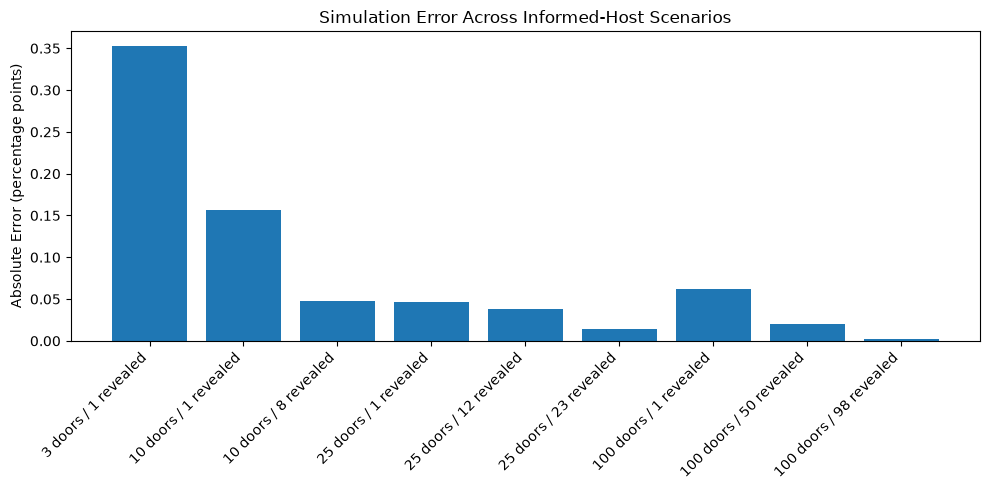

In [65]:
plt.figure(figsize=(10, 5))

plt.bar(
    accuracy_df["Scenario"],
    accuracy_df["Absolute Error (pp)"],
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Absolute Error (percentage points)")
plt.title("Simulation Error Across Informed-Host Scenarios")

finish_plot("simulation_accuracy.png")

## 25. Variability across scenarios

The same number of trials can produce different amounts of percentage fluctuation depending on the underlying probability.

We compare three scenarios using many repeated batches.

In [66]:
stability_scenarios = [
    ("Classic: 3 doors / 1 revealed", 3, 1),
    ("100 doors / 1 revealed", 100, 1),
    ("100 doors / 98 revealed", 100, 98),
]

stability_records = []

for scenario_index, (name, n_doors, reveals) in enumerate(stability_scenarios):
    for batch in range(STABILITY_BATCHES):
        result = simulate_rates(
            STABILITY_BATCH_SIZE,
            n_doors=n_doors,
            reveals=reveals,
            host_knows=True,
            seed=BASE_SEED + 4_000_000 + scenario_index * 10_000 + batch,
        )

        stability_records.append(
            {
                "Scenario": name,
                "Batch": batch + 1,
                "Switch Win Rate (%)": result["Switch Win Rate"] * 100,
            }
        )

stability_df = pd.DataFrame(stability_records)

stability_summary = (
    stability_df.groupby("Scenario")["Switch Win Rate (%)"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(
        columns={
            "mean": "Mean (%)",
            "std": "Std Dev (pp)",
            "min": "Minimum (%)",
            "max": "Maximum (%)",
        }
    )
)

stability_summary.round(3)

,Scenario,Mean (%),Std Dev (pp),Minimum (%),Maximum (%)
0,100 doors / 1 revealed,1.046,0.237,0.5,1.5
1,100 doors / 98 revealed,99.004,0.294,98.4,99.7
2,Classic: 3 doors / 1 revealed,66.468,1.431,63.4,69.0


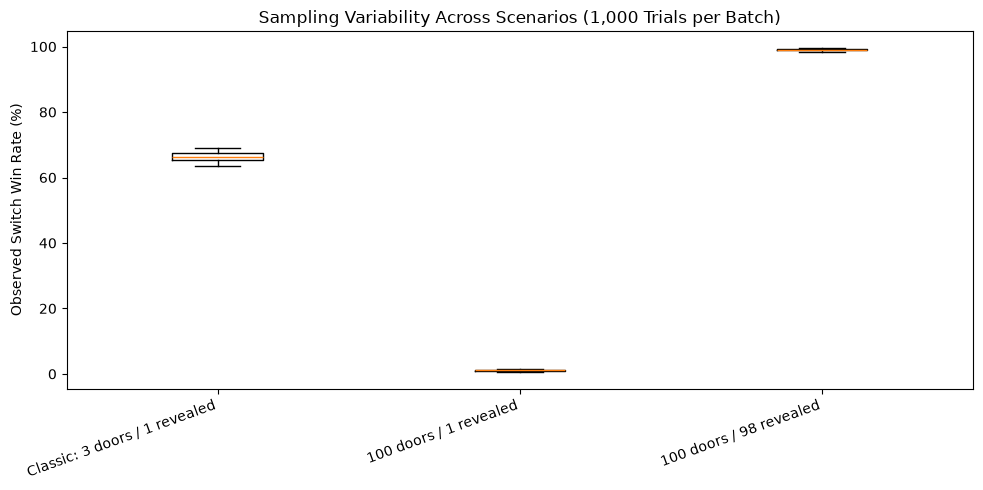

In [67]:
plt.figure(figsize=(10, 5))

box_data = [
    stability_df.loc[
        stability_df["Scenario"] == name,
        "Switch Win Rate (%)",
    ]
    for name, _, _ in stability_scenarios
]

plt.boxplot(
    box_data,
    tick_labels=[name for name, _, _ in stability_scenarios],
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Observed Switch Win Rate (%)")
plt.title(
    f"Sampling Variability Across Scenarios "
    f"({STABILITY_BATCH_SIZE:,} Trials per Batch)"
)

finish_plot("scenario_variability.png")

# Part VII — Optional interactive experiment

## 26. Interactive controls

If `ipywidgets` is installed, this cell creates controls for:

- total doors,
- doors revealed,
- trial count,
- seed,
- whether the host knows the prize.

The reveal slider automatically updates so it never exceeds `doors - 2`.

This section is useful when running the notebook locally in Jupyter or VS Code. Static exports such as PDF will show the code but not provide live interactivity.

In [68]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    door_widget = widgets.IntSlider(
        value=10,
        min=3,
        max=100,
        step=1,
        description="Doors:",
        continuous_update=False,
    )

    reveal_widget = widgets.IntSlider(
        value=1,
        min=0,
        max=8,
        step=1,
        description="Reveals:",
        continuous_update=False,
    )

    games_widget = widgets.IntSlider(
        value=10_000,
        min=100,
        max=100_000,
        step=100,
        description="Trials:",
        continuous_update=False,
    )

    seed_widget = widgets.IntText(
        value=42,
        description="Seed:",
    )

    host_widget = widgets.ToggleButtons(
        options=[
            ("Host knows prize", True),
            ("Host does not know", False),
        ],
        value=True,
        description="Host:",
    )

    run_button = widgets.Button(
        description="Run experiment",
        button_style="primary",
    )

    output_widget = widgets.Output()

    def update_reveal_max(change=None):
        reveal_widget.max = door_widget.value - 2
        if reveal_widget.value > reveal_widget.max:
            reveal_widget.value = reveal_widget.max

    door_widget.observe(update_reveal_max, names="value")
    update_reveal_max()

    def run_interactive_experiment(_):
        with output_widget:
            clear_output()

            result = simulate_rates(
                games_widget.value,
                n_doors=door_widget.value,
                reveals=reveal_widget.value,
                host_knows=host_widget.value,
                seed=seed_widget.value,
            )

            if host_widget.value:
                theory = informed_theory(
                    door_widget.value,
                    reveal_widget.value,
                )

                table = pd.DataFrame(
                    [
                        {
                            "Strategy": "Stay",
                            "Observed (%)": result["Stay Win Rate"] * 100,
                            "Theoretical (%)": theory["Stay"] * 100,
                        },
                        {
                            "Strategy": "Switch",
                            "Observed (%)": result["Switch Win Rate"] * 100,
                            "Theoretical (%)": theory["Switch"] * 100,
                        },
                    ]
                )
            else:
                theory = uninformed_theory(
                    door_widget.value,
                    reveal_widget.value,
                )

                table = pd.DataFrame(
                    [
                        {
                            "Metric": "Stay win rate — all rounds",
                            "Observed (%)": result["Stay Win Rate"] * 100,
                            "Theoretical (%)": theory["Stay Unconditional"] * 100,
                        },
                        {
                            "Metric": "Switch win rate — all rounds",
                            "Observed (%)": result["Switch Win Rate"] * 100,
                            "Theoretical (%)": theory["Switch Unconditional"] * 100,
                        },
                        {
                            "Metric": "Host revealed prize",
                            "Observed (%)": result["Host Revealed Prize Rate"] * 100,
                            "Theoretical (%)": theory["Host Reveals Prize"] * 100,
                        },
                        {
                            "Metric": "Switch win rate — completed rounds",
                            "Observed (%)": result["Switch Completed Win Rate"] * 100,
                            "Theoretical (%)": theory["Switch Conditional"] * 100,
                        },
                    ]
                )

            display(table.round(3))

    run_button.on_click(run_interactive_experiment)

    display(
        widgets.VBox(
            [
                door_widget,
                reveal_widget,
                games_widget,
                seed_widget,
                host_widget,
                run_button,
                output_widget,
            ]
        )
    )

except ImportError:
    print(
        "ipywidgets is not installed. Run "
        "`python -m pip install ipywidgets` "
        "to enable the interactive controls."
    )

# Part VIII — Conclusions

The extended experiments show several important ideas:

1. **Switching is not magically better just because a door was opened.**
   The host's knowledge and reveal policy matter.

2. **An informed host transfers probability mass.**
   The more known losing doors Monty removes, the more valuable the remaining alternatives become.

3. **An uninformed host behaves differently.**
   The host can reveal the prize, and conditional on surviving that reveal, staying and random switching have the same probability under this model.

4. **More trials reduce simulation noise.**
   Small experiments fluctuate substantially; large experiments tend to converge toward theoretical probability.

5. **The classic Monty Hall problem is an extreme information case.**
   With many doors, revealing only one losing door barely helps. Revealing every possible losing door can make switching overwhelmingly favorable.

# Command-line simulator

The companion `simulator.py` supports:

```text
--games
--doors
--reveals
--host informed|uninformed
--seed
--output
```

Examples:

```bash
python simulator.py --games 1000000 --doors 3 --reveals 1 --host informed --seed 42 --output classic.csv
```

```bash
python simulator.py --games 1000000 --doors 100 --reveals 1 --host informed --seed 42 --output one_reveal.csv
```

```bash
python simulator.py --games 1000000 --doors 100 --reveals 98 --host informed --seed 42 --output max_reveal.csv
```

```bash
python simulator.py --games 100000 --doors 10 --reveals 3 --host uninformed --seed 42 --output uninformed.csv
```

You can also use:

```bash
python simulator.py --reveals max
```

to reveal the maximum possible number of doors (`doors - 2`).